# Système Intelligent de Filtrage des Emails pour la Sécurité des Communications #

**Chargement des donnees et Importation des bibliotheque**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re


In [2]:
#df=pd.read_csv(r'C:\Users\saido\Desktop\Simplon\Brief3\EmailAimodel\DataSet_Emails.csv')
df= pd.read_csv('DataSet_Emails.csv')
df.head()

,Unnamed: 0,message_id,text,label,label_text,subject,message,date
0,0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


Afficher les informations de chaque columms 

In [3]:
df.info()
print('la taille des donnes',df.shape)
print('le nombre de columns est :',df.shape[1],'le nombre des ligne',df.shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31716 entries, 0 to 31715
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  31716 non-null  int64 
 1   message_id  31716 non-null  int64 
 2   text        31665 non-null  object
 3   label       31716 non-null  int64 
 4   label_text  31716 non-null  object
 5   subject     31442 non-null  object
 6   message     31371 non-null  object
 7   date        31716 non-null  object
dtypes: int64(3), object(5)
memory usage: 1.9+ MB
la taille des donnes (31716, 8)
le nombre de columns est : 8 le nombre des ligne 31716


Le DataFrame contient 31716 lignes et 8 colonnes.

Les colonnes sont de types int64 (3 colonnes) et object (5 colonnes).

Certaines colonnes ont des valeurs manquantes :

text : 51 valeurs manquantes

subject : 274 valeurs manquantes

message : 345 valeurs manquantes

La mémoire utilisée est d’environ 1.9 Mo.

Les colonnes Unnamed: 0 et message_id semblent être des identifiants.

# Gestion des valeurs manquantes #

In [4]:
df.isnull().sum()

Unnamed: 0      0
message_id      0
text           51
label           0
label_text      0
subject       274
message       345
date            0
dtype: int64

In [5]:
#  Supprimer les lignes où la colonne 'text' est vide ou manquante
df = df.dropna(subset=['text','message','subject'])  

In [6]:
df.isnull().sum()

Unnamed: 0    0
message_id    0
text          0
label         0
label_text    0
subject       0
message       0
date          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df[df['text'].str.strip() != '']        # supprime les chaînes vides (" ")

#  Convertir tout le texte en minuscules
df['text'] = df['text'].str.lower()

df.head()

,Unnamed: 0,message_id,text,label,label_text,subject,message,date
0,0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


Détecter les valeurs manquantes

La taille de DataSet apres la supprition

In [9]:
print('la taille de dataSet',df.shape)

la taille de dataSet (31148, 8)


**Difference entre colonne message et text**

In [10]:
print(df['text'][0])
print(df['message'][0])

any software just for 15 $ - 99 $ understanding oem software
lead me not into temptation ; i can find the way myself .
# 3533 . the law disregards trifles .
understanding oem software
lead me not into temptation ; i can find the way myself .
# 3533 . the law disregards trifles .


Compter et visualiser la distribution des classes (Spam vs Ham)

In [11]:
counts=df['label_text'].value_counts()
print(counts)

label_text
spam    15645
ham     15503
Name: count, dtype: int64


**Suppression des colonnes inutiles**

In [12]:
df=df.drop(['Unnamed: 0','message_id'],axis=1)
df.head()

,text,label,label_text,subject,message,date
0,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


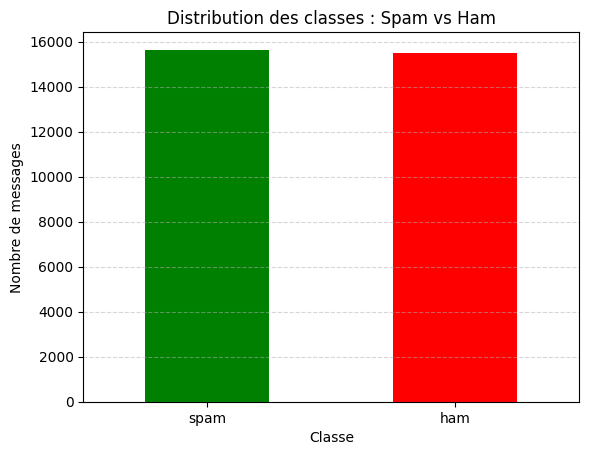

In [13]:
import matplotlib.pyplot as plt

# Affichage sous forme d'histogramme
counts.plot(kind='bar', color=['green', 'red'])

plt.title('Distribution des classes : Spam vs Ham')
plt.xlabel('Classe')
plt.ylabel('Nombre de messages')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


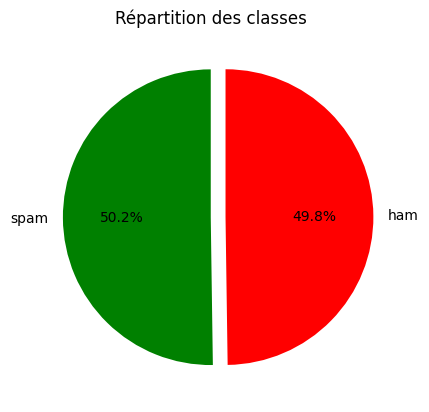

In [14]:
# Camembert
counts.plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'], startangle=90, explode=(0, 0.1))

plt.title('Répartition des classes')
plt.ylabel('')  # Supprimer le label par défaut
plt.show()


Créer des wordclouds pour les spams et les ham

In [15]:
from wordcloud import WordCloud

Séparer les textes Spam et Ham

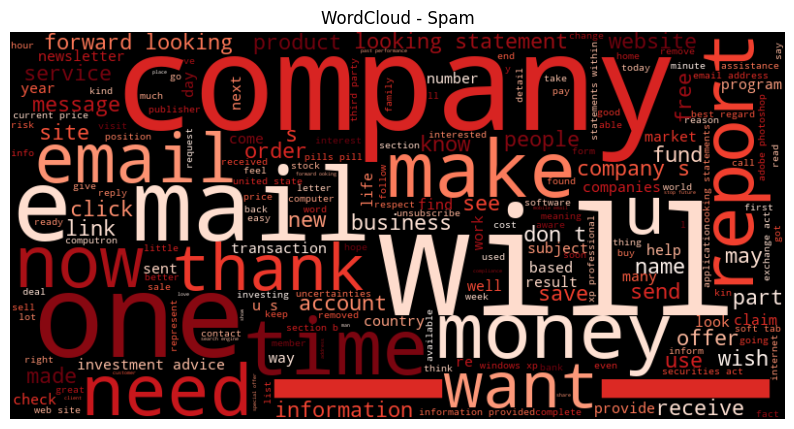

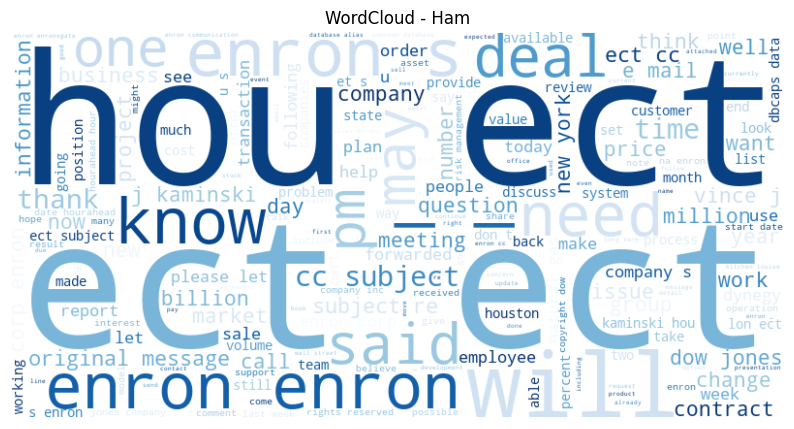

In [16]:
spam_text = " ".join(df[df['label_text'] == "spam"]['text'].astype(str))
ham_text = " ".join(df[df['label_text'] == "ham"]['text'].astype(str))

plt.figure(figsize=(10,6))
wc_spam = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(spam_text)
plt.imshow(wc_spam, interpolation='bilinear'); 
plt.axis("off"); 
plt.title("WordCloud - Spam")
plt.show()

plt.figure(figsize=(10,6))
wc_ham = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(ham_text)
plt.imshow(wc_ham, interpolation='bilinear'); 
plt.axis("off"); 
plt.title("WordCloud - Ham")
plt.show()

Longueur moyenne en caractères

In [17]:
# Ajouter une colonne 'length' contenant la longueur de chaque message
df['length'] = df['text'].astype(str).apply(len)

# Longueur moyenne
mean_length = df['length'].mean()
print(f"Longueur moyenne des messages (caractères) : {mean_length:.2f}")


Longueur moyenne des messages (caractères) : 1526.48


**Suppression des ponctuations et des caractères spéciaux**

In [18]:
import re

# Fonction de nettoyage
def nettoyer_ponctuation(text):
    # Supprimer tout sauf les lettres et les espaces
    return re.sub(r'[^a-zA-Z\s]', '', text)

# Appliquer à la colonne 'text'
df['text'] = df['text'].astype(str).apply(nettoyer_ponctuation)
df.head()

,text,label,label_text,subject,message,date,length
0,any software just for understanding oem s...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18,156
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19,1112
2,wanted to try ci lis but thought it was way t...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11,242
3,enron hpl actuals for december teco tap ...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12,127
4,looking for cheap high quality software rota...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13,329


Suppression des stopwords (nltk)

Supprimer les stopwords de la colonne text

In [19]:
import nltk
from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Télécharger les ressources nécessaires une seule fois
nltk.download('punkt')
nltk.download('stopwords')

# Initialiser les outils
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# 1. Tokenisation
df['tokens'] = df['text'].apply(lambda x: wordpunct_tokenize(x.lower()))

# 2. Suppression des stopwords et des caractères non alphabétiques
df['filtered_tokens'] = df['tokens'].apply(lambda tokens: [t for t in tokens if t.isalpha() and t not in stop_words])

# 3. Stemming
df['stemmed_tokens'] = df['filtered_tokens'].apply(lambda tokens: [stemmer.stem(t) for t in tokens])

# 4. Reconstruction du texte nettoyé
df['clean_text'] = df['stemmed_tokens'].apply(lambda tokens: ' '.join(tokens))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saido\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saido\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
df.head()

,text,label,label_text,subject,message,date,length,tokens,filtered_tokens,stemmed_tokens,clean_text
0,any software just for understanding oem s...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18,156,"[any, software, just, for, understanding, oem,...","[software, understanding, oem, software, lead,...","[softwar, understand, oem, softwar, lead, temp...",softwar understand oem softwar lead temptat fi...
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19,1112,"[perspective, on, ferc, regulatory, action, cl...","[perspective, ferc, regulatory, action, client...","[perspect, ferc, regulatori, action, client, c...",perspect ferc regulatori action client conf ca...
2,wanted to try ci lis but thought it was way t...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11,242,"[wanted, to, try, ci, lis, but, thought, it, w...","[wanted, try, ci, lis, thought, way, expensive...","[want, tri, ci, li, thought, way, expens, viag...",want tri ci li thought way expens viagra per d...
3,enron hpl actuals for december teco tap ...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12,127,"[enron, hpl, actuals, for, december, teco, tap...","[enron, hpl, actuals, december, teco, tap, enr...","[enron, hpl, actual, decemb, teco, tap, enron,...",enron hpl actual decemb teco tap enron hpl ga ...
4,looking for cheap high quality software rota...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13,329,"[looking, for, cheap, high, quality, software,...","[looking, cheap, high, quality, software, rota...","[look, cheap, high, qualiti, softwar, rotat, n...",look cheap high qualiti softwar rotat napoleon...


Utiliser TfidfVectorizer

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['clean_text'])  # df['clean_text'] contient le texte prétraité

print(vectorizer.get_feature_names_out())   # Liste des mots conservés
print(X)
print("Taille matrice TF-IDF :", X.shape)

X_array = X.toarray()
X_tfidf = pd.DataFrame(X_array, columns=vectorizer.get_feature_names_out())  
X_tfidf.head()  

['aa' 'ab' 'abil' ... 'zero' 'zimin' 'zone']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1954843 stored elements and shape (31148, 3000)>
  Coords	Values
  (0, 2471)	0.5835219594676393
  (0, 2791)	0.30384811200829615
  (0, 1850)	0.4259843420006189
  (0, 1504)	0.3309589594679747
  (0, 1050)	0.2643930480740883
  (0, 2902)	0.2610053547604445
  (0, 1498)	0.3716913720853408
  (1, 1975)	0.19745567963964492
  (1, 1035)	0.47062678843104894
  (1, 2206)	0.18118642801067802
  (1, 28)	0.34892617446679447
  (1, 495)	0.15815509999716332
  (1, 378)	0.20291332163571021
  (1, 2704)	0.15877475757793177
  (1, 1441)	0.1114525691165815
  (1, 2671)	0.1151171827382584
  (1, 2022)	0.1465125621011886
  (1, 558)	0.14989231654651453
  (1, 2766)	0.06957757177857737
  (1, 1442)	0.07264343207636156
  (1, 1264)	0.08711598805838275
  (1, 2162)	0.2036902087468478
  (1, 2046)	0.11533293857982406
  (1, 1779)	0.1383157562081861
  (1, 1128)	0.1136785001447536
  :	:
  (31147, 598)	0.2469414667127432
  (31

,aa,ab,abil,abl,abroad,absenc,absolut,abus,ac,academ,...,year,yesterday,yet,yield,yo,york,young,zero,zimin,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Définir X (features) et y (cible)

In [22]:
df.head()

,text,label,label_text,subject,message,date,length,tokens,filtered_tokens,stemmed_tokens,clean_text
0,any software just for understanding oem s...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18,156,"[any, software, just, for, understanding, oem,...","[software, understanding, oem, software, lead,...","[softwar, understand, oem, softwar, lead, temp...",softwar understand oem softwar lead temptat fi...
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19,1112,"[perspective, on, ferc, regulatory, action, cl...","[perspective, ferc, regulatory, action, client...","[perspect, ferc, regulatori, action, client, c...",perspect ferc regulatori action client conf ca...
2,wanted to try ci lis but thought it was way t...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11,242,"[wanted, to, try, ci, lis, but, thought, it, w...","[wanted, try, ci, lis, thought, way, expensive...","[want, tri, ci, li, thought, way, expens, viag...",want tri ci li thought way expens viagra per d...
3,enron hpl actuals for december teco tap ...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12,127,"[enron, hpl, actuals, for, december, teco, tap...","[enron, hpl, actuals, december, teco, tap, enr...","[enron, hpl, actual, decemb, teco, tap, enron,...",enron hpl actual decemb teco tap enron hpl ga ...
4,looking for cheap high quality software rota...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13,329,"[looking, for, cheap, high, quality, software,...","[looking, cheap, high, quality, software, rota...","[look, cheap, high, qualiti, softwar, rotat, n...",look cheap high qualiti softwar rotat napoleon...


In [23]:
# Définir la variable cible y
X = X_tfidf
y = df['label']  


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrainement du modèle #

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression



models = {
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": LinearSVC(),
    "Logistic Regression": LogisticRegression()  # Augmenter max_iter pour convergence

}

In [26]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f" {name} entraîné avec succès.")

 Naive Bayes entraîné avec succès.
 Decision Tree entraîné avec succès.
 SVM entraîné avec succès.
 Logistic Regression entraîné avec succès.


# Évaluation des performances #

In [27]:
trained_models = {name: model for name, model in models.items()}



 Évaluation du modèle : Naive Bayes
Matrice de confusion :
[[2947   85]
 [  35 3163]]


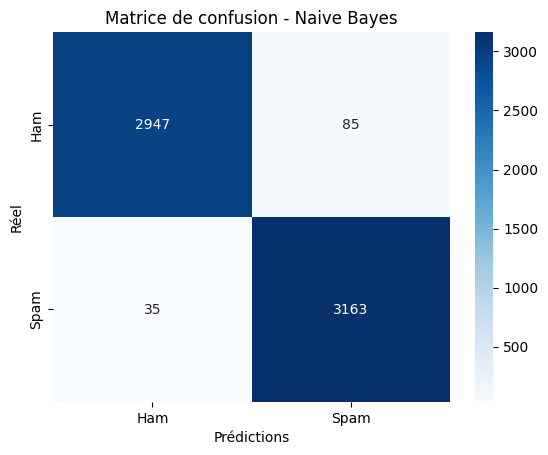

********************************************************************************
Classification Report :
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98      3032
        Spam       0.97      0.99      0.98      3198

    accuracy                           0.98      6230
   macro avg       0.98      0.98      0.98      6230
weighted avg       0.98      0.98      0.98      6230

********************************************************************************
Scores individuels :
Accuracy : 0.9807
Precision : 0.9738
Recall : 0.9891
F1-score : 0.9814

 Évaluation du modèle : Decision Tree
Matrice de confusion :
[[2889  143]
 [ 141 3057]]


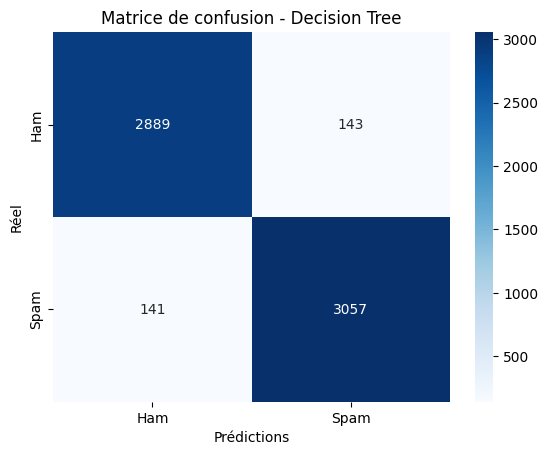

********************************************************************************
Classification Report :
              precision    recall  f1-score   support

         Ham       0.95      0.95      0.95      3032
        Spam       0.96      0.96      0.96      3198

    accuracy                           0.95      6230
   macro avg       0.95      0.95      0.95      6230
weighted avg       0.95      0.95      0.95      6230

********************************************************************************
Scores individuels :
Accuracy : 0.9544
Precision : 0.9553
Recall : 0.9559
F1-score : 0.9556

 Évaluation du modèle : SVM
Matrice de confusion :
[[2986   46]
 [  31 3167]]


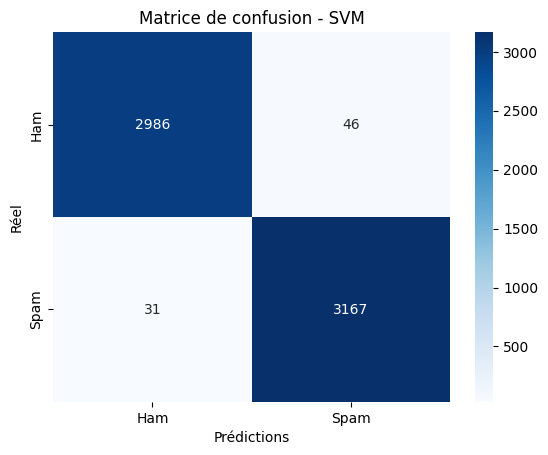

********************************************************************************
Classification Report :
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      3032
        Spam       0.99      0.99      0.99      3198

    accuracy                           0.99      6230
   macro avg       0.99      0.99      0.99      6230
weighted avg       0.99      0.99      0.99      6230

********************************************************************************
Scores individuels :
Accuracy : 0.9876
Precision : 0.9857
Recall : 0.9903
F1-score : 0.9880

 Évaluation du modèle : Logistic Regression
Matrice de confusion :
[[2966   66]
 [  22 3176]]


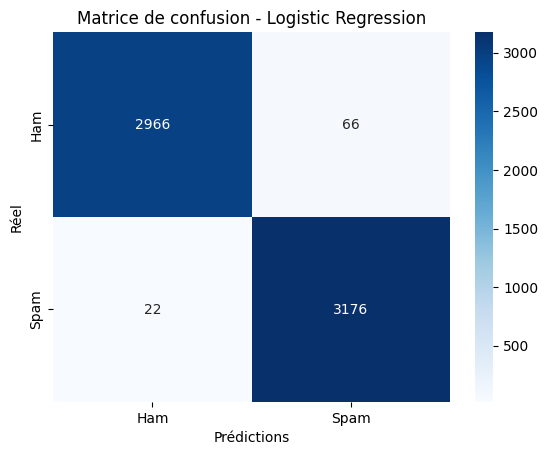

********************************************************************************
Classification Report :
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      3032
        Spam       0.98      0.99      0.99      3198

    accuracy                           0.99      6230
   macro avg       0.99      0.99      0.99      6230
weighted avg       0.99      0.99      0.99      6230

********************************************************************************
Scores individuels :
Accuracy : 0.9859
Precision : 0.9796
Recall : 0.9931
F1-score : 0.9863


In [28]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Évaluation sur les modèles entraînés
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"\n Évaluation du modèle : {name}")
##Calculer la Matrice de Confusion
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f"Matrice de confusion - {name}")
    plt.xlabel('Prédictions')
    plt.ylabel('Réel')
    plt.show()

    print("**"*40)
    print("Classification Report :")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
#Calculer précision, rappel, F1-score
    print("**"*40)
    print("Scores individuels :")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

# Validation croisée #

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

trained_models = {
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": LinearSVC(),
    "Logistic Regression": LogisticRegression()  # Augmenter max_iter pour convergence
    }
print("\n Validation croisée (5-fold) :")
for name, model in trained_models.items():
    f1_scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    print(f"{name} - F1 Score moyen : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")


 Validation croisée (5-fold) :
Naive Bayes - F1 Score moyen : 0.9793 ± 0.0007
Decision Tree - F1 Score moyen : 0.9552 ± 0.0022
SVM - F1 Score moyen : 0.9872 ± 0.0005
Logistic Regression - F1 Score moyen : 0.9850 ± 0.0012


# Optimisation des hyperparamètres #

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
import joblib

# Définir les modèles avec leurs grilles d'hyperparamètres
models_with_grids = {
    "Naive Bayes": {
        "model": MultinomialNB(),
        "params": {"alpha": [0.01, 0.1, 1.0]}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    },
    "SVM": {
        "model": LinearSVC(dual=False),
        "params": {"C": [0.1, 1, 10], "max_iter": [1000, 3000]}
    },
    "Logistic Regression": {
        "model": LogisticRegression(solver='liblinear'),
        "params": {"C": [0.01, 0.1, 1], "penalty": ["l1", "l2"]}
    }
}

print("🔍 Validation croisée uniquement (sans test set) avec GridSearchCV :")

best_model = None
best_score = 0
best_name = ""

for name, entry in models_with_grids.items():
    print(f"\n=== {name} ===")
    grid = GridSearchCV(entry["model"], entry["params"], cv=5, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)

    print("✅ Meilleurs paramètres :", grid.best_params_)
    print("📊 Meilleur F1-score (CV) :", grid.best_score_)

    if grid.best_score_ > best_score:
        best_model = grid.best_estimator_
        best_score = grid.best_score_
        best_name = name

🔍 Validation croisée uniquement (sans test set) avec GridSearchCV :

=== Naive Bayes ===
✅ Meilleurs paramètres : {'alpha': 0.01}
📊 Meilleur F1-score (CV) : 0.9784889538782237

=== Decision Tree ===
✅ Meilleurs paramètres : {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
📊 Meilleur F1-score (CV) : 0.952041904394218

=== SVM ===
✅ Meilleurs paramètres : {'C': 1, 'max_iter': 1000}
📊 Meilleur F1-score (CV) : 0.9858734513960974

=== Logistic Regression ===
✅ Meilleurs paramètres : {'C': 1, 'penalty': 'l2'}
📊 Meilleur F1-score (CV) : 0.9843879025319989


Sauvegarde du meilleur modèle

In [31]:
import joblib
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
# ✅ Sauvegarder le meilleur modèle
joblib.dump(best_model, "model.pkl")
print(f"\n🏆 Meilleur modèle : {best_name} (F1-CV = {best_score:.4f})")
print("💾 Modèle sauvegardé dans model.pkl")


🏆 Meilleur modèle : SVM (F1-CV = 0.9859)
💾 Modèle sauvegardé dans model.pkl


In [32]:
import joblib
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

Détecter l’overfitting

In [33]:
from sklearn.metrics import accuracy_score, f1_score

# Exemple : pour un modèle déjà entraîné (par ex. best_model)
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Évaluer la performance
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Affichage des résultats
print("🔍 Évaluation du surapprentissage (overfitting) :")
print(f"Accuracy - Entraînement : {train_acc:.4f}")
print(f"Accuracy - Test        : {test_acc:.4f}")

print(f"F1-score - Entraînement : {train_f1:.4f}")
print(f"F1-score - Test         : {test_f1:.4f}")

# Interprétation simple
if train_f1 - test_f1 > 0.1:
    print("Le modèle est probablement en overfitting.")
elif test_f1 > train_f1:
    print("Le modèle généralise bien (pas d'overfitting).")
else:
    print("Le modèle semble bien équilibré.")


🔍 Évaluation du surapprentissage (overfitting) :
Accuracy - Entraînement : 0.9974
Accuracy - Test        : 0.9876
F1-score - Entraînement : 0.9974
F1-score - Test         : 0.9876
Le modèle semble bien équilibré.
